In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset Details
Name : OpenMarineStream v1.0: Raw Multi-Sensor Marine Time Series for Online Anomaly Detection

It is a raw multi-sensor marine time series dataset created for research on online anomaly detection, sensor fusion, and concept drift in environmental monitoring systems. The archive contains nine CSV files, each representing an individual sensor stream exported over the period 10-28 to 10-30:

Link: [Water](https://zenodo.org/records/18177103)

In [2]:
!pip install prophet

#**Loading Files**

In [3]:
import pandas as pd

temp_file = "/content/drive/MyDrive/C3_Temperature_10-28_10-30.csv"
turb_file = "/content/drive/MyDrive/C3_Turbidity_10-28_10-30.csv"
sal_file  = "/content/drive/MyDrive/SEB45_Salinity_10-28_10-30.csv"

col_names = ["timestamp_raw", "value", "geometry", "timestamp"]

temp_df = pd.read_csv(temp_file, header=None, names=col_names)
turb_df = pd.read_csv(turb_file, header=None, names=col_names)
sal_df  = pd.read_csv(sal_file,  header=None, names=col_names)

print("Temperature")
display(temp_df.head())

print("Turbidity")
display(turb_df.head())

print("Salinity")
display(sal_df.head())

Temperature


,timestamp_raw,value,geometry,timestamp
0,2021-10-28T00:00:00.000+0000,30.219999,"{""Type"":""Point"",""Coordinates"":[-62.63885498046...",2021-10-28T00:00:00
1,2021-10-28T00:01:00.000+0000,30.230000,"{""Type"":""Point"",""Coordinates"":[-62.63905334472...",2021-10-28T00:01:00
2,2021-10-28T00:02:00.000+0000,30.219999,"{""Type"":""Point"",""Coordinates"":[-62.63927078247...",2021-10-28T00:02:00
3,2021-10-28T00:03:00.000+0000,30.230000,"{""Type"":""Point"",""Coordinates"":[-62.63948822021...",2021-10-28T00:03:00
4,2021-10-28T00:04:00.000+0000,30.230000,"{""Type"":""Point"",""Coordinates"":[-62.63969039916...",2021-10-28T00:04:00


Turbidity


,timestamp_raw,value,geometry,timestamp
0,2021-10-28T00:00:00.000+0000,1.18,"{""Type"":""Point"",""Coordinates"":[-62.63885498046...",2021-10-28T00:00:00
1,2021-10-28T00:01:00.000+0000,1.17,"{""Type"":""Point"",""Coordinates"":[-62.63905334472...",2021-10-28T00:01:00
2,2021-10-28T00:02:00.000+0000,1.17,"{""Type"":""Point"",""Coordinates"":[-62.63927078247...",2021-10-28T00:02:00
3,2021-10-28T00:03:00.000+0000,1.18,"{""Type"":""Point"",""Coordinates"":[-62.63948822021...",2021-10-28T00:03:00
4,2021-10-28T00:04:00.000+0000,1.10,"{""Type"":""Point"",""Coordinates"":[-62.63969039916...",2021-10-28T00:04:00


Salinity


,timestamp_raw,value,geometry,timestamp
0,2021-10-28T00:00:00.000+0000,34.324,"{""Type"":""Point"",""Coordinates"":[-62.63885498046...",2021-10-28T00:00:00
1,2021-10-28T00:01:00.000+0000,34.324,"{""Type"":""Point"",""Coordinates"":[-62.63905334472...",2021-10-28T00:01:00
2,2021-10-28T00:02:00.000+0000,34.322,"{""Type"":""Point"",""Coordinates"":[-62.63927078247...",2021-10-28T00:02:00
3,2021-10-28T00:03:00.000+0000,34.324,"{""Type"":""Point"",""Coordinates"":[-62.63948822021...",2021-10-28T00:03:00
4,2021-10-28T00:04:00.000+0000,34.321,"{""Type"":""Point"",""Coordinates"":[-62.63969039916...",2021-10-28T00:04:00


#**Temparature**

##**Preparing dataset for Prophet**

In [4]:
temp_prophet = temp_df[["timestamp", "value"]].copy()
temp_prophet.columns = ["ds", "y"]

temp_prophet["ds"] = pd.to_datetime(temp_prophet["ds"], errors="coerce")
temp_prophet["y"] = pd.to_numeric(temp_prophet["y"], errors="coerce")

temp_prophet = temp_prophet.dropna().drop_duplicates(subset=["ds"]).sort_values("ds")

display(temp_prophet.head())
print(temp_prophet.shape)

,ds,y
0,2021-10-28 00:00:00,30.219999
1,2021-10-28 00:01:00,30.230000
2,2021-10-28 00:02:00,30.219999
3,2021-10-28 00:03:00,30.230000
4,2021-10-28 00:04:00,30.230000


(4316, 2)


##**Plot the raw data before modeling**

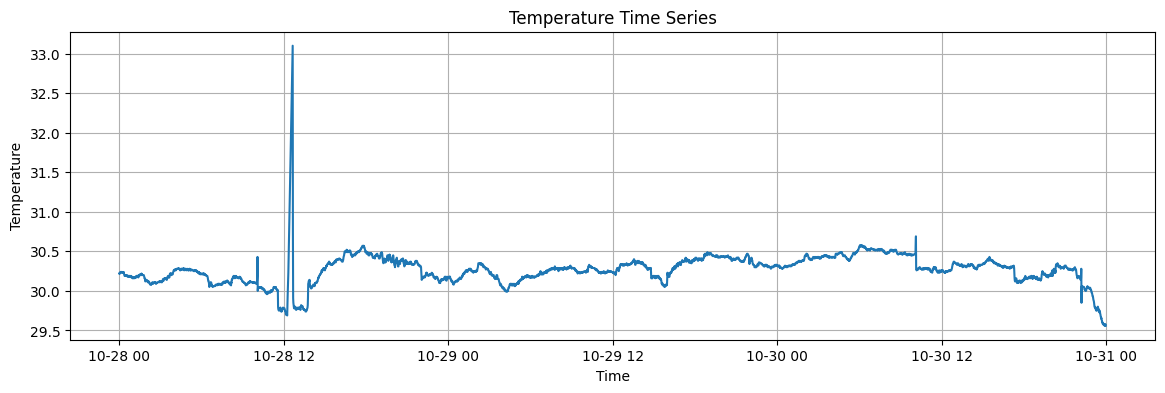

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(temp_prophet["ds"], temp_prophet["y"])
plt.title("Temperature Time Series")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.grid(True)
plt.show()

##**FItting Prophet On Temparature**

In [7]:
test_size = 1000

train_temp = temp_prophet.iloc[:-test_size].copy()
test_temp  = temp_prophet.iloc[-test_size:].copy()

print("Train shape:", train_temp.shape)
print("Test shape:", test_temp.shape)

from prophet import Prophet

model_temp = Prophet(
    daily_seasonality=True,
    weekly_seasonality=False,
    yearly_seasonality=False
)

model_temp.fit(train_temp)

Train shape: (3316, 2)
Test shape: (1000, 2)


##**Forecast the next 120 minutes**

In [8]:
future_temp = model_temp.make_future_dataframe(periods=test_size, freq="min")
forecast_temp = model_temp.predict(future_temp)

display(forecast_temp[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())

,ds,yhat,yhat_lower,yhat_upper
4311,2021-10-30 23:52:00,30.738163,25.481176,35.989752
4312,2021-10-30 23:53:00,30.738204,25.332311,35.959714
4313,2021-10-30 23:54:00,30.738257,25.288531,35.951964
4314,2021-10-30 23:55:00,30.738323,25.471193,36.072764
4315,2021-10-30 23:56:00,30.738402,25.388031,35.926316


##**Compare Forecast vs Actual**

,ds,yhat,y
0,2021-10-30 07:17:00,30.526205,30.52
1,2021-10-30 07:18:00,30.526133,30.51
2,2021-10-30 07:19:00,30.526046,30.51
3,2021-10-30 07:20:00,30.525943,30.51
4,2021-10-30 07:21:00,30.525824,30.51


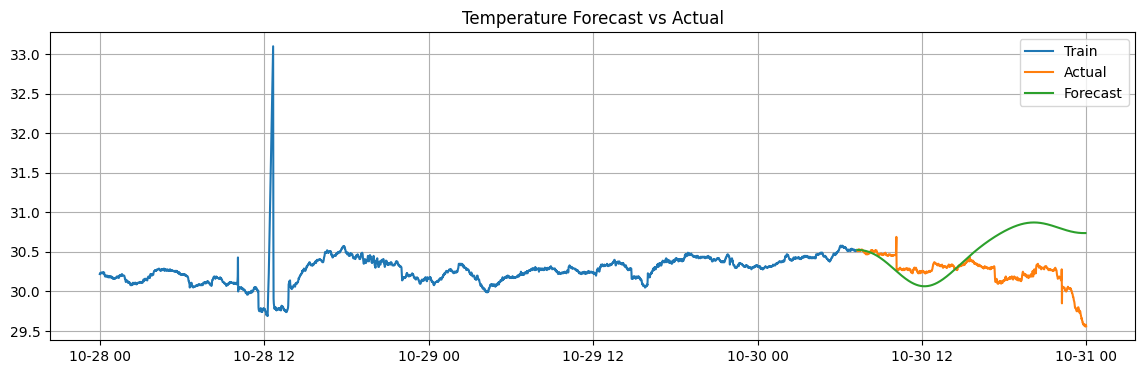

In [9]:
forecast_test_temp = forecast_temp[["ds", "yhat"]].merge(
    test_temp, on="ds", how="inner"
)

display(forecast_test_temp.head())
plt.figure(figsize=(14,4))
plt.plot(train_temp["ds"], train_temp["y"], label="Train")
plt.plot(test_temp["ds"], test_temp["y"], label="Actual")
plt.plot(forecast_test_temp["ds"], forecast_test_temp["yhat"], label="Forecast")
plt.legend()
plt.title("Temperature Forecast vs Actual")
plt.grid(True)
plt.show()

##**Measure Errors**

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_temp = mean_absolute_error(forecast_test_temp["y"], forecast_test_temp["yhat"])
mse_temp = mean_squared_error(forecast_test_temp["y"], forecast_test_temp["yhat"])
rmse_temp = np.sqrt(mse_temp)

print("Temperature MAE :", mae_temp)
print("Temperature MSE :", mse_temp)
print("Temperature RMSE:", rmse_temp)

Temperature MAE : 0.3523910619021537
Temperature MSE : 0.21286903358080678
Temperature RMSE: 0.46137732235211426


##**Plot Temparature Errors**

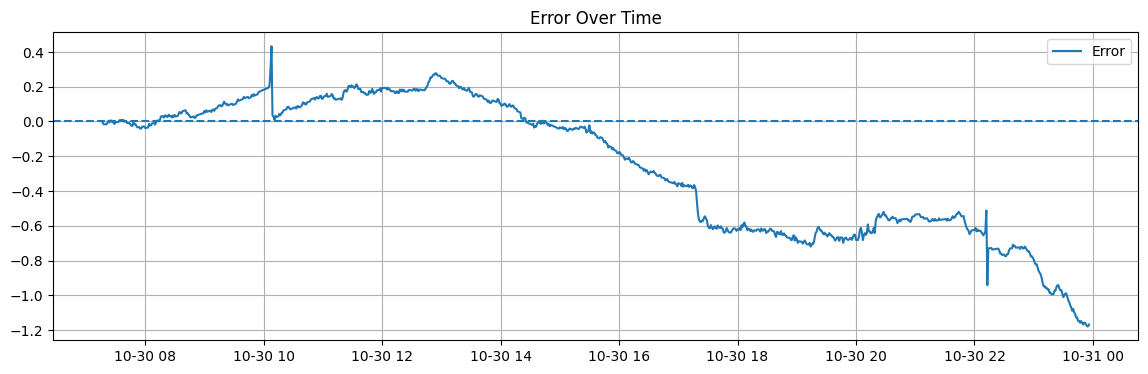

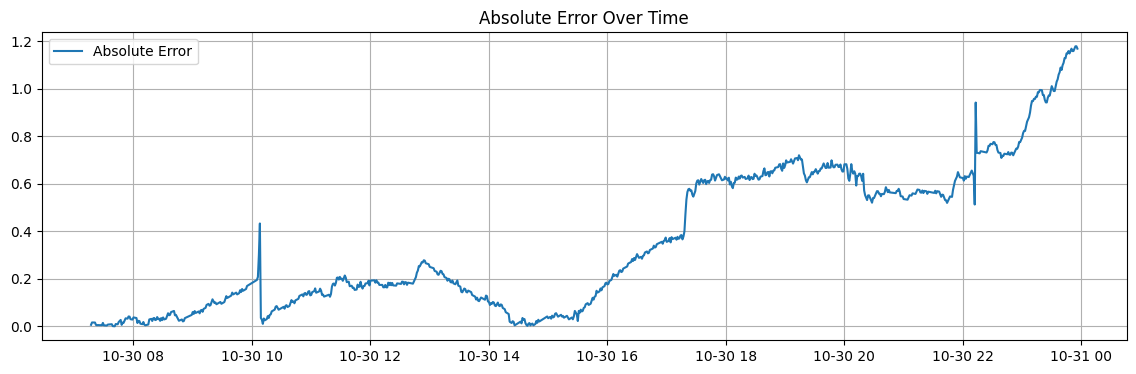

In [11]:
forecast_test_temp["error"] = forecast_test_temp["y"] - forecast_test_temp["yhat"]
forecast_test_temp["abs_error"] = forecast_test_temp["error"].abs()

plt.figure(figsize=(14,4))
plt.plot(forecast_test_temp["ds"], forecast_test_temp["error"], label="Error")
plt.axhline(0, linestyle="--")
plt.legend()
plt.grid(True)
plt.title("Error Over Time")
plt.show()

plt.figure(figsize=(14,4))
plt.plot(forecast_test_temp["ds"], forecast_test_temp["abs_error"], label="Absolute Error")
plt.legend()
plt.grid(True)
plt.title("Absolute Error Over Time")
plt.show()

#**Turbidity**

## **Prepare Prophet input**

In [12]:
turb_prophet = turb_df[["timestamp", "value"]].copy()
turb_prophet.columns = ["ds", "y"]

turb_prophet["ds"] = pd.to_datetime(turb_prophet["ds"], errors="coerce")
turb_prophet["y"] = pd.to_numeric(turb_prophet["y"], errors="coerce")

turb_prophet = turb_prophet.dropna().drop_duplicates(subset=["ds"]).sort_values("ds")

display(turb_prophet.head())
print(turb_prophet.shape)

,ds,y
0,2021-10-28 00:00:00,1.18
1,2021-10-28 00:01:00,1.17
2,2021-10-28 00:02:00,1.17
3,2021-10-28 00:03:00,1.18
4,2021-10-28 00:04:00,1.10


(4316, 2)


## **Plot raw turbidity series**

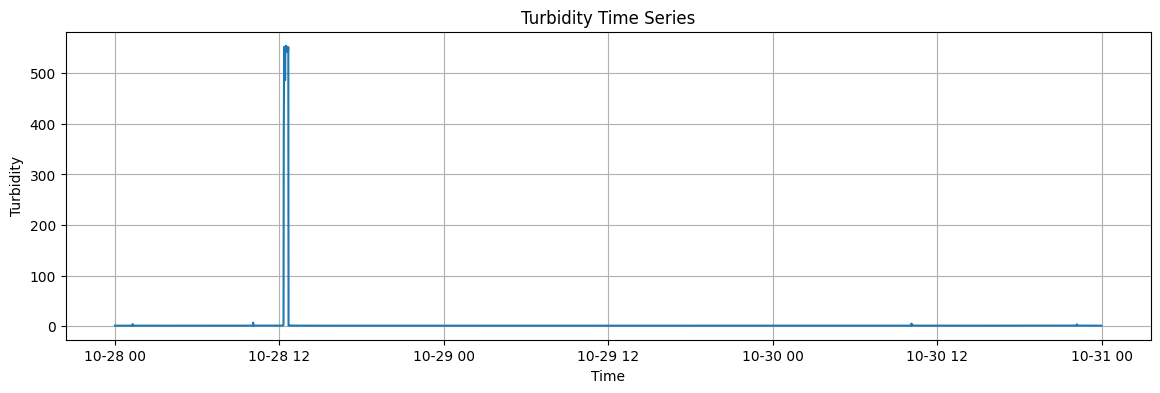

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(turb_prophet["ds"], turb_prophet["y"])
plt.title("Turbidity Time Series")
plt.xlabel("Time")
plt.ylabel("Turbidity")
plt.grid(True)
plt.show()

## **Train-test split**

In [14]:
test_size = 1000

train_turb = turb_prophet.iloc[:-test_size].copy()
test_turb  = turb_prophet.iloc[-test_size:].copy()

print("Train shape:", train_turb.shape)
print("Test shape:", test_turb.shape)

Train shape: (3316, 2)
Test shape: (1000, 2)


## **Fit Prophet**

In [15]:
from prophet import Prophet

model_turb = Prophet(
    daily_seasonality=True,
    weekly_seasonality=False,
    yearly_seasonality=False
)

model_turb.fit(train_turb)

## **Forecast next test window**

In [16]:
future_turb = model_turb.make_future_dataframe(periods=test_size, freq="min")
forecast_turb = model_turb.predict(future_turb)

display(forecast_turb[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())

,ds,yhat,yhat_lower,yhat_upper
4311,2021-10-30 23:52:00,8.314725,-45.297440,59.356436
4312,2021-10-30 23:53:00,8.381280,-46.703702,64.325644
4313,2021-10-30 23:54:00,8.446818,-46.257821,61.317163
4314,2021-10-30 23:55:00,8.511318,-45.932349,63.399810
4315,2021-10-30 23:56:00,8.574760,-42.139756,63.923072


## **Compare forecast vs actual**

In [17]:
forecast_test_turb = forecast_turb[["ds", "yhat"]].merge(
    test_turb, on="ds", how="inner"
)

display(forecast_test_turb.head())


,ds,yhat,y
0,2021-10-30 07:17:00,-3.316314,1.23
1,2021-10-30 07:18:00,-3.446911,1.22
2,2021-10-30 07:19:00,-3.577759,1.18
3,2021-10-30 07:20:00,-3.708817,1.18
4,2021-10-30 07:21:00,-3.840047,1.15


## **Plot actual vs predicted**

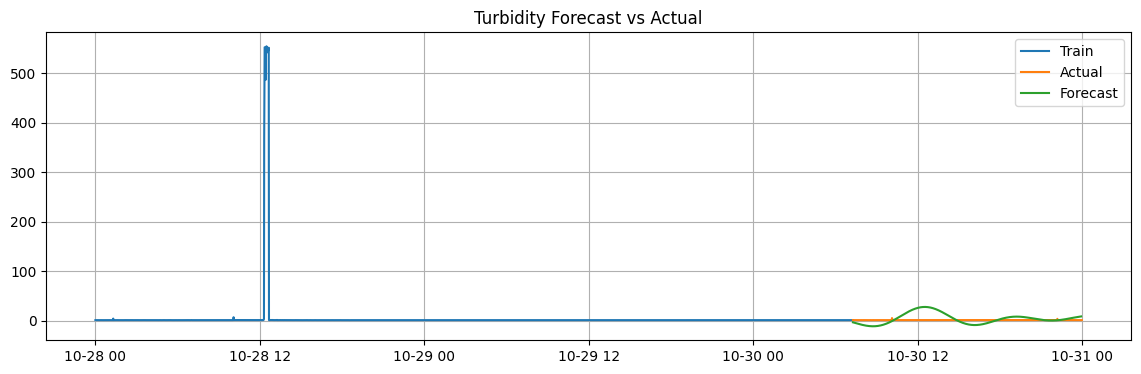

In [18]:
plt.figure(figsize=(14,4))
plt.plot(train_turb["ds"], train_turb["y"], label="Train")
plt.plot(test_turb["ds"], test_turb["y"], label="Actual")
plt.plot(forecast_test_turb["ds"], forecast_test_turb["yhat"], label="Forecast")
plt.legend()
plt.title("Turbidity Forecast vs Actual")
plt.grid(True)
plt.show()

## **Measure errors**

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_turb = mean_absolute_error(forecast_test_turb["y"], forecast_test_turb["yhat"])
rmse_turb = np.sqrt(mean_squared_error(forecast_test_turb["y"], forecast_test_turb["yhat"]))

print("Turbidity MAE:", mae_turb)
print("Turbidity RMSE:", rmse_turb)

Turbidity MAE: 8.432107631020719
Turbidity RMSE: 11.080856890775733


## **Plot turbidity errors**

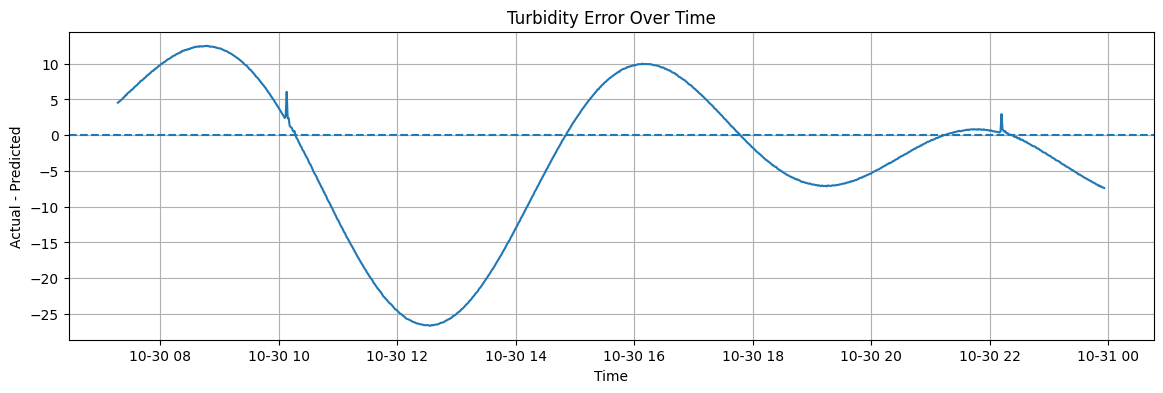

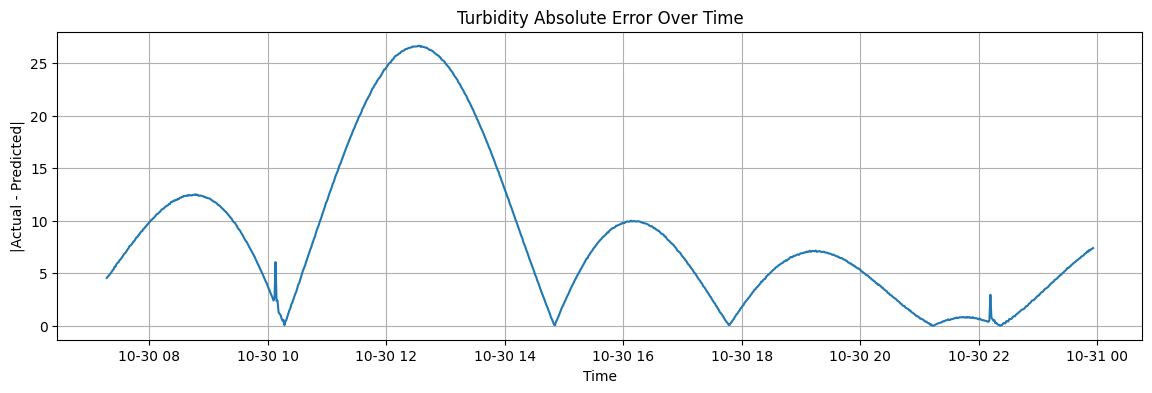

In [20]:
forecast_test_turb["error"] = forecast_test_turb["y"] - forecast_test_turb["yhat"]
forecast_test_turb["abs_error"] = forecast_test_turb["error"].abs()

plt.figure(figsize=(14,4))
plt.plot(forecast_test_turb["ds"], forecast_test_turb["error"])
plt.axhline(0, linestyle="--")
plt.title("Turbidity Error Over Time")
plt.xlabel("Time")
plt.ylabel("Actual - Predicted")
plt.grid(True)
plt.show()

plt.figure(figsize=(14,4))
plt.plot(forecast_test_turb["ds"], forecast_test_turb["abs_error"])
plt.title("Turbidity Absolute Error Over Time")
plt.xlabel("Time")
plt.ylabel("|Actual - Predicted|")
plt.grid(True)
plt.show()

#**Salinity**

## **Prepare Prophet input**

In [21]:
sal_prophet = sal_df[["timestamp", "value"]].copy()
sal_prophet.columns = ["ds", "y"]

sal_prophet["ds"] = pd.to_datetime(sal_prophet["ds"], errors="coerce")
sal_prophet["y"] = pd.to_numeric(sal_prophet["y"], errors="coerce")

sal_prophet = sal_prophet.dropna().drop_duplicates(subset=["ds"]).sort_values("ds")

display(sal_prophet.head())
print(sal_prophet.shape)

,ds,y
0,2021-10-28 00:00:00,34.324
1,2021-10-28 00:01:00,34.324
2,2021-10-28 00:02:00,34.322
3,2021-10-28 00:03:00,34.324
4,2021-10-28 00:04:00,34.321


(4316, 2)


## **Plot raw salinity series**

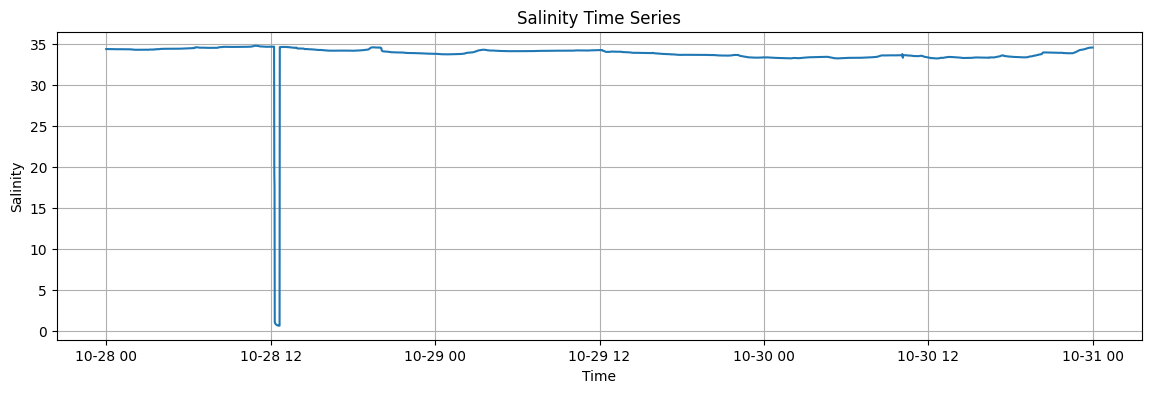

In [22]:
plt.figure(figsize=(14,4))
plt.plot(sal_prophet["ds"], sal_prophet["y"])
plt.title("Salinity Time Series")
plt.xlabel("Time")
plt.ylabel("Salinity")
plt.grid(True)
plt.show()

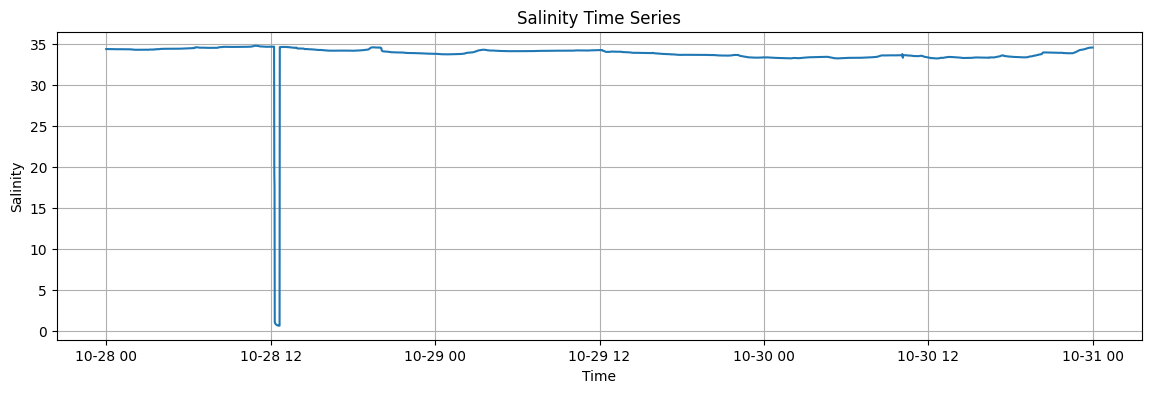

In [23]:
plt.figure(figsize=(14,4))
plt.plot(sal_prophet["ds"], sal_prophet["y"])
plt.title("Salinity Time Series")
plt.xlabel("Time")
plt.ylabel("Salinity")
plt.grid(True)
plt.show()

## **Train-test split**

In [24]:
test_size = 1000

train_sal = sal_prophet.iloc[:-test_size].copy()
test_sal  = sal_prophet.iloc[-test_size:].copy()

print("Train shape:", train_sal.shape)
print("Test shape:", test_sal.shape)

Train shape: (3316, 2)
Test shape: (1000, 2)


## **Fit Prophet**

In [25]:
model_sal = Prophet(
    daily_seasonality=True,
    weekly_seasonality=False,
    yearly_seasonality=False
)

model_sal.fit(train_sal)

## **Forecast next test window**

In [26]:
future_sal = model_sal.make_future_dataframe(periods=test_size, freq="min")
forecast_sal = model_sal.predict(future_sal)

display(forecast_sal[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())

,ds,yhat,yhat_lower,yhat_upper
4311,2021-10-30 23:52:00,31.679023,28.037986,35.383734
4312,2021-10-30 23:53:00,31.673573,27.935332,35.273949
4313,2021-10-30 23:54:00,31.668215,28.254903,35.299855
4314,2021-10-30 23:55:00,31.662951,28.305719,35.432276
4315,2021-10-30 23:56:00,31.657782,28.049605,35.130419


## **Compare forecast vs actual**

In [27]:
forecast_test_sal = forecast_sal[["ds", "yhat"]].merge(
    test_sal, on="ds", how="inner"
)

display(forecast_test_sal.head())

,ds,yhat,y
0,2021-10-30 07:17:00,33.550689,33.275002
1,2021-10-30 07:18:00,33.559594,33.275002
2,2021-10-30 07:19:00,33.568517,33.275002
3,2021-10-30 07:20:00,33.577455,33.272999
4,2021-10-30 07:21:00,33.586405,33.276001


## **Plot actual vs predicted**



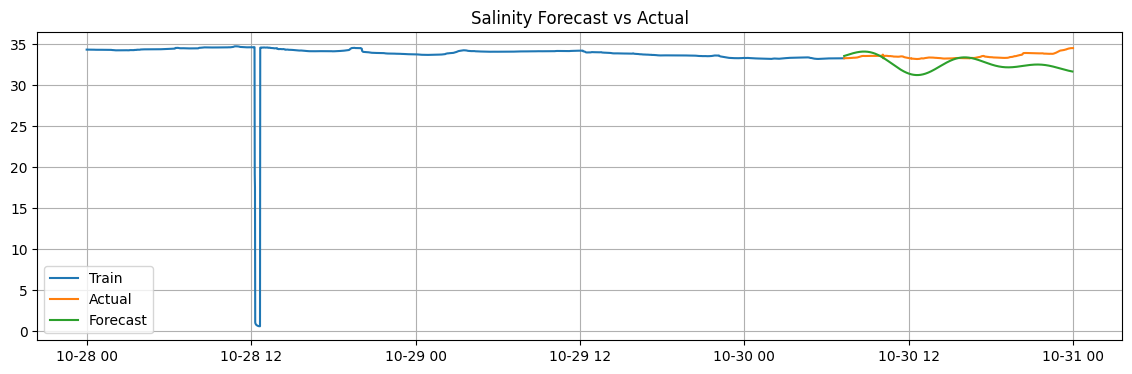

In [28]:
plt.figure(figsize=(14,4))
plt.plot(train_sal["ds"], train_sal["y"], label="Train")
plt.plot(test_sal["ds"], test_sal["y"], label="Actual")
plt.plot(forecast_test_sal["ds"], forecast_test_sal["yhat"], label="Forecast")
plt.legend()
plt.title("Salinity Forecast vs Actual")
plt.grid(True)
plt.show()

## **Measure errors**

In [29]:
mae_sal = mean_absolute_error(forecast_test_sal["y"], forecast_test_sal["yhat"])
rmse_sal = np.sqrt(mean_squared_error(forecast_test_sal["y"], forecast_test_sal["yhat"]))

print("Salinity MAE:", mae_sal)
print("Salinity RMSE:", rmse_sal)

Salinity MAE: 1.0676199176226868
Salinity RMSE: 1.2735604741104578


## **Plot salinity errors**

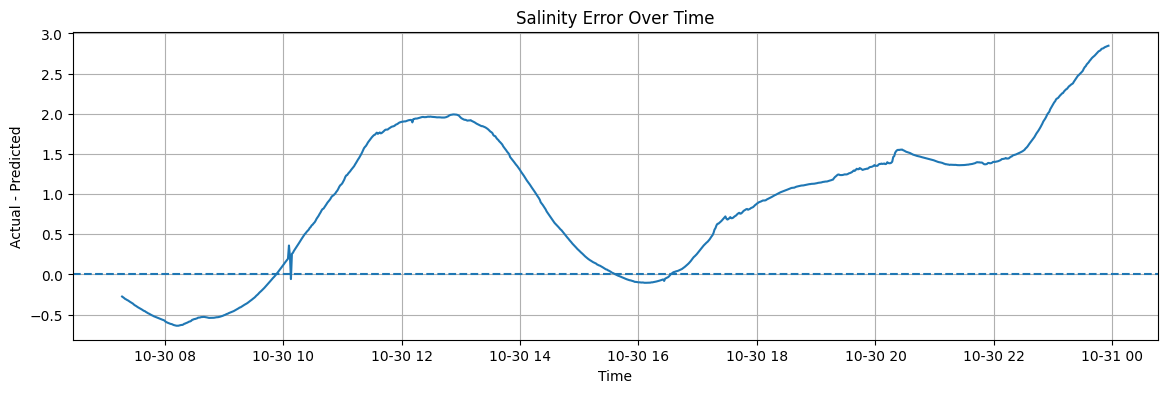

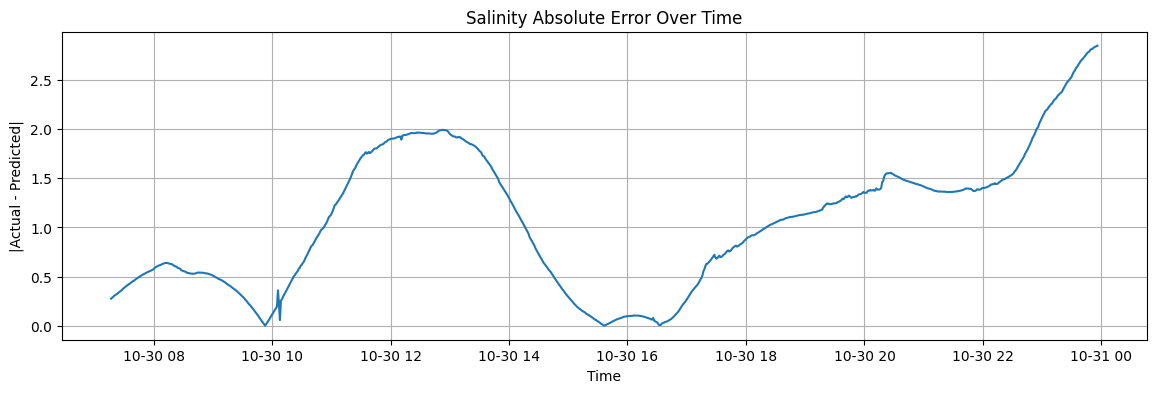

In [30]:
forecast_test_sal["error"] = forecast_test_sal["y"] - forecast_test_sal["yhat"]
forecast_test_sal["abs_error"] = forecast_test_sal["error"].abs()

plt.figure(figsize=(14,4))
plt.plot(forecast_test_sal["ds"], forecast_test_sal["error"])
plt.axhline(0, linestyle="--")
plt.title("Salinity Error Over Time")
plt.xlabel("Time")
plt.ylabel("Actual - Predicted")
plt.grid(True)
plt.show()

plt.figure(figsize=(14,4))
plt.plot(forecast_test_sal["ds"], forecast_test_sal["abs_error"])
plt.title("Salinity Absolute Error Over Time")
plt.xlabel("Time")
plt.ylabel("|Actual - Predicted|")
plt.grid(True)
plt.show()

# **Isolation Forest**


## Separate anomalies for each dataset

### **Temperature only**

Temperature anomalies: 40


,timestamp,temperature,anomaly,anomaly_score
735,2021-10-28 12:15:00,29.690001,-1,-0.005322
744,2021-10-28 12:24:00,30.820000,-1,-0.010692
745,2021-10-28 12:25:00,31.000000,-1,-0.022831
746,2021-10-28 12:26:00,31.180000,-1,-0.041487
747,2021-10-28 12:27:00,31.330000,-1,-0.054487


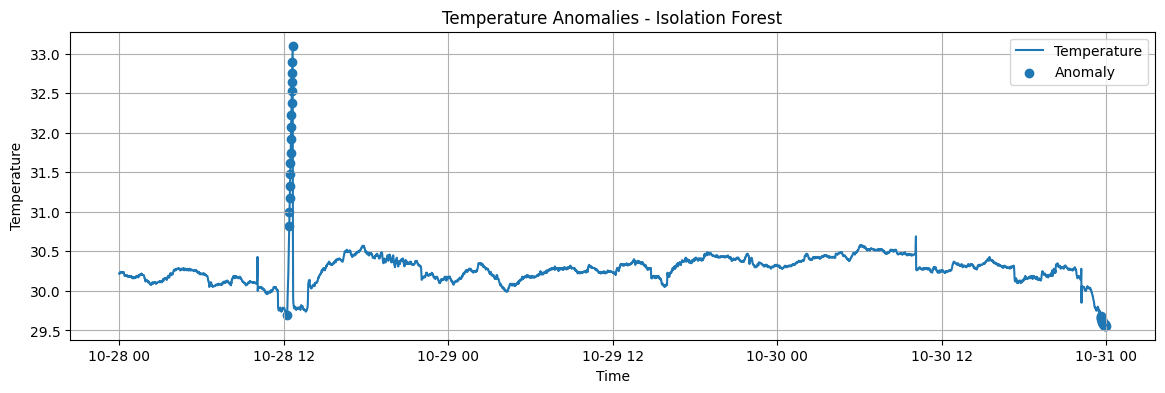

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

temp_only = temp_df[["timestamp", "value"]].copy()
temp_only.columns = ["timestamp", "temperature"]

temp_only["timestamp"] = pd.to_datetime(temp_only["timestamp"], errors="coerce")
temp_only["temperature"] = pd.to_numeric(temp_only["temperature"], errors="coerce")
temp_only = temp_only.dropna().drop_duplicates(subset=["timestamp"]).sort_values("timestamp")

iso_temp = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

temp_only["anomaly"] = iso_temp.fit_predict(temp_only[["temperature"]])
temp_only["anomaly_score"] = iso_temp.decision_function(temp_only[["temperature"]])

temp_anomalies = temp_only[temp_only["anomaly"] == -1].copy()

print("Temperature anomalies:", len(temp_anomalies))
display(temp_anomalies.head())

plt.figure(figsize=(14,4))
plt.plot(temp_only["timestamp"], temp_only["temperature"], label="Temperature")
plt.scatter(temp_anomalies["timestamp"], temp_anomalies["temperature"], label="Anomaly")
plt.title("Temperature Anomalies - Isolation Forest")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

### **Turbidity only**


Turbidity anomalies: 43


,timestamp,turbidity,anomaly,anomaly_score
78,2021-10-28 01:18:00,4.21,-1,-0.080009
605,2021-10-28 10:05:00,7.00,-1,-0.083891
736,2021-10-28 12:16:00,1.71,-1,-0.049344
737,2021-10-28 12:17:00,1.94,-1,-0.059256
738,2021-10-28 12:18:00,3.99,-1,-0.080009


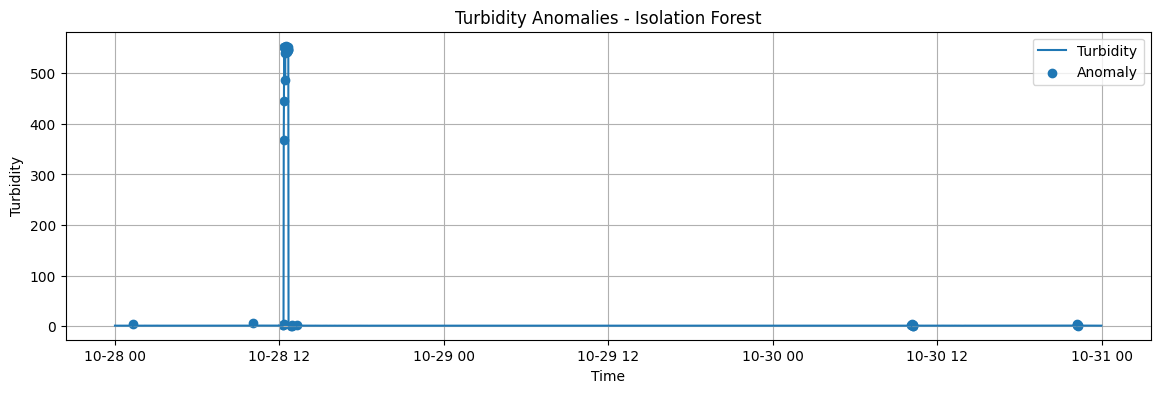

In [32]:
turb_only = turb_df[["timestamp", "value"]].copy()
turb_only.columns = ["timestamp", "turbidity"]

turb_only["timestamp"] = pd.to_datetime(turb_only["timestamp"], errors="coerce")
turb_only["turbidity"] = pd.to_numeric(turb_only["turbidity"], errors="coerce")
turb_only = turb_only.dropna().drop_duplicates(subset=["timestamp"]).sort_values("timestamp")

iso_turb = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

turb_only["anomaly"] = iso_turb.fit_predict(turb_only[["turbidity"]])
turb_only["anomaly_score"] = iso_turb.decision_function(turb_only[["turbidity"]])

turb_anomalies = turb_only[turb_only["anomaly"] == -1].copy()

print("Turbidity anomalies:", len(turb_anomalies))
display(turb_anomalies.head())

plt.figure(figsize=(14,4))
plt.plot(turb_only["timestamp"], turb_only["turbidity"], label="Turbidity")
plt.scatter(turb_anomalies["timestamp"], turb_anomalies["turbidity"], label="Anomaly")
plt.title("Turbidity Anomalies - Isolation Forest")
plt.xlabel("Time")
plt.ylabel("Turbidity")
plt.legend()
plt.grid(True)
plt.show()

### **Salinity only**

Salinity anomalies: 44


,timestamp,salinity,anomaly,anomaly_score
646,2021-10-28 10:46:00,34.702,-1,-0.001764
647,2021-10-28 10:47:00,34.711,-1,-0.009165
648,2021-10-28 10:48:00,34.721,-1,-0.016196
649,2021-10-28 10:49:00,34.724,-1,-0.018031
650,2021-10-28 10:50:00,34.725,-1,-0.017572


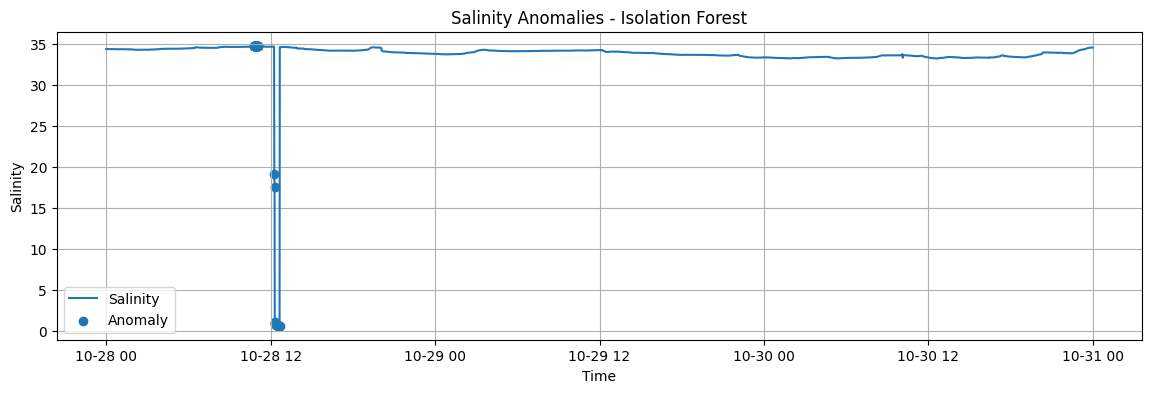

In [33]:
sal_only = sal_df[["timestamp", "value"]].copy()
sal_only.columns = ["timestamp", "salinity"]

sal_only["timestamp"] = pd.to_datetime(sal_only["timestamp"], errors="coerce")
sal_only["salinity"] = pd.to_numeric(sal_only["salinity"], errors="coerce")
sal_only = sal_only.dropna().drop_duplicates(subset=["timestamp"]).sort_values("timestamp")

iso_sal = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

sal_only["anomaly"] = iso_sal.fit_predict(sal_only[["salinity"]])
sal_only["anomaly_score"] = iso_sal.decision_function(sal_only[["salinity"]])

sal_anomalies = sal_only[sal_only["anomaly"] == -1].copy()

print("Salinity anomalies:", len(sal_anomalies))
display(sal_anomalies.head())

plt.figure(figsize=(14,4))
plt.plot(sal_only["timestamp"], sal_only["salinity"], label="Salinity")
plt.scatter(sal_anomalies["timestamp"], sal_anomalies["salinity"], label="Anomaly")
plt.title("Salinity Anomalies - Isolation Forest")
plt.xlabel("Time")
plt.ylabel("Salinity")
plt.legend()
plt.grid(True)
plt.show()

## **Combined anomalies using all three together**

### **Prepare and merge**

In [34]:
temp_data = temp_df[["timestamp", "value"]].copy()
temp_data.columns = ["timestamp", "temperature"]

turb_data = turb_df[["timestamp", "value"]].copy()
turb_data.columns = ["timestamp", "turbidity"]

sal_data = sal_df[["timestamp", "value"]].copy()
sal_data.columns = ["timestamp", "salinity"]

for df in [temp_data, turb_data, sal_data]:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

temp_data["temperature"] = pd.to_numeric(temp_data["temperature"], errors="coerce")
turb_data["turbidity"] = pd.to_numeric(turb_data["turbidity"], errors="coerce")
sal_data["salinity"] = pd.to_numeric(sal_data["salinity"], errors="coerce")

temp_data = temp_data.dropna().drop_duplicates(subset=["timestamp"]).sort_values("timestamp")
turb_data = turb_data.dropna().drop_duplicates(subset=["timestamp"]).sort_values("timestamp")
sal_data = sal_data.dropna().drop_duplicates(subset=["timestamp"]).sort_values("timestamp")

merged_df = temp_data.merge(turb_data, on="timestamp", how="inner")
merged_df = merged_df.merge(sal_data, on="timestamp", how="inner")

print("Merged shape:", merged_df.shape)
display(merged_df.head())

Merged shape: (4316, 4)


,timestamp,temperature,turbidity,salinity
0,2021-10-28 00:00:00,30.219999,1.18,34.324
1,2021-10-28 00:01:00,30.230000,1.17,34.324
2,2021-10-28 00:02:00,30.219999,1.17,34.322
3,2021-10-28 00:03:00,30.230000,1.18,34.324
4,2021-10-28 00:04:00,30.230000,1.10,34.321


## **Scale and fit Isolation Forest**

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

features = ["temperature", "turbidity", "salinity"]
X = merged_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso_all = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

merged_df["status"] = iso_all.fit_predict(X_scaled)
# Map numeric status to descriptive strings
merged_df["status"] = merged_df["status"].map({-1: "anomaly", 1: "normal"})
merged_df["anomaly_score"] = iso_all.decision_function(X_scaled)

# all_anomalies should now be based on the string 'anomaly'
all_anomalies = merged_df[merged_df["status"] == "anomaly"].copy()

In [47]:
print("Displaying the full merged DataFrame with anomaly status:")
display(merged_df.tail()) # Displaying head to not overload the output
print("\n... (showing first 5 rows, but the entire DataFrame has 4316 rows)\n")
display(merged_df[merged_df["status"] == "anomaly"].head()) # Displaying head of anomalies for quick check
print("\n... (showing first 5 anomalies, all anomalies are tagged in the 'status' column of the full dataframe)")

Displaying the full merged DataFrame with anomaly status:


,timestamp,temperature,turbidity,salinity,anomaly,anomaly_score,status
4311,2021-10-30 23:55:00,29.559999,1.18,34.506001,1,0.034388,normal
4312,2021-10-30 23:56:00,29.570000,1.18,34.505001,1,0.036026,normal
4313,2021-10-30 23:57:00,29.570000,1.16,34.507000,1,0.030373,normal
4314,2021-10-30 23:58:00,29.580000,1.21,34.506001,1,0.028043,normal
4315,2021-10-30 23:59:00,29.559999,1.16,34.507000,1,0.028927,normal



... (showing first 5 rows, but the entire DataFrame has 4316 rows)



,timestamp,temperature,turbidity,salinity,anomaly,anomaly_score,status
78,2021-10-28 01:18:00,30.190001,4.21,34.303,-1,-0.027736,anomaly
605,2021-10-28 10:05:00,30.430000,7.00,34.591,-1,-0.067116,anomaly
736,2021-10-28 12:16:00,29.850000,1.71,19.154,-1,-0.099466,anomaly
737,2021-10-28 12:17:00,29.940001,1.94,17.537,-1,-0.104127,anomaly
738,2021-10-28 12:18:00,30.030001,3.99,1.109,-1,-0.134628,anomaly



... (showing first 5 anomalies, all anomalies are tagged in the 'status' column of the full dataframe)


In [45]:
output_dir = '/content/drive/MyDrive/'

# Save merged_df with anomaly status
merged_df.to_csv(f"{output_dir}combined_data_with_anomaly_status.csv", index=False)

# Save all_anomalies
all_anomalies.to_csv(f"{output_dir}identified_anomalies.csv", index=False)

print("DataFrames saved successfully to Google Drive!")

DataFrames saved successfully to Google Drive!


## **Plot combined anomalies on each variable**

### **Temperature**

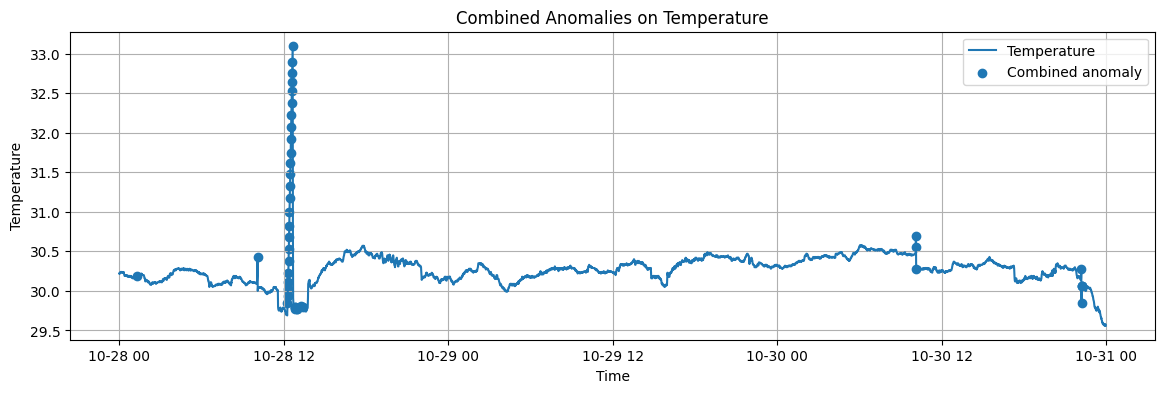

In [48]:
plt.figure(figsize=(14,4))
plt.plot(merged_df["timestamp"], merged_df["temperature"], label="Temperature")
plt.scatter(all_anomalies["timestamp"], all_anomalies["temperature"], label="Combined anomaly")
plt.title("Combined Anomalies on Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

### **Turbidity**

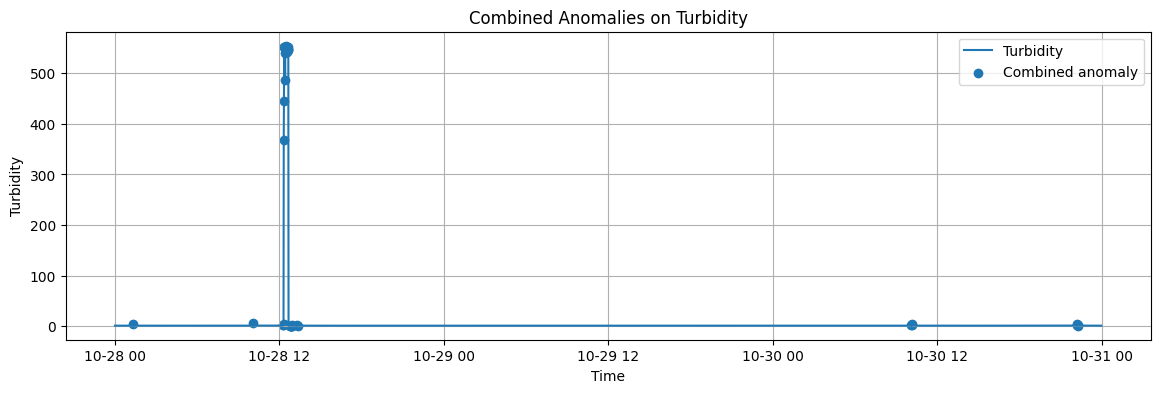

In [49]:
plt.figure(figsize=(14,4))
plt.plot(merged_df["timestamp"], merged_df["turbidity"], label="Turbidity")
plt.scatter(all_anomalies["timestamp"], all_anomalies["turbidity"], label="Combined anomaly")
plt.title("Combined Anomalies on Turbidity")
plt.xlabel("Time")
plt.ylabel("Turbidity")
plt.legend()
plt.grid(True)
plt.show()

### **Salinity**

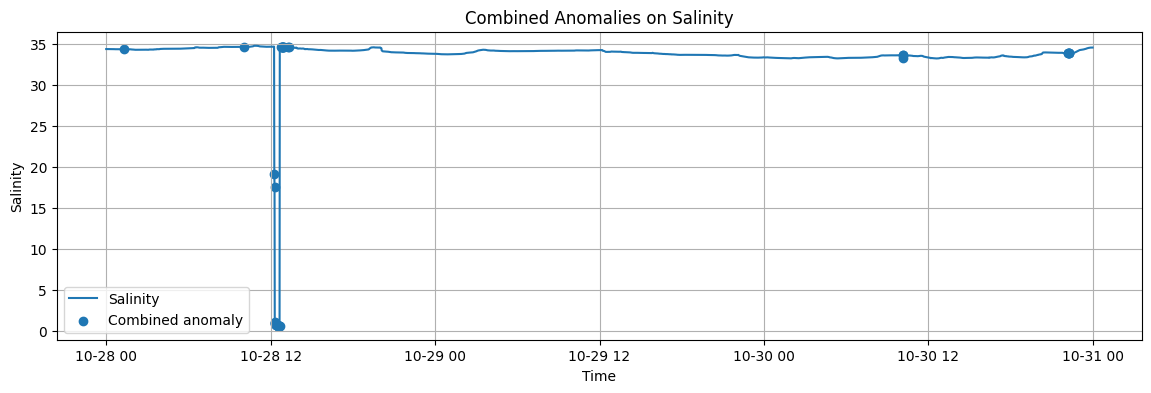

In [50]:
plt.figure(figsize=(14,4))
plt.plot(merged_df["timestamp"], merged_df["salinity"], label="Salinity")
plt.scatter(all_anomalies["timestamp"], all_anomalies["salinity"], label="Combined anomaly")
plt.title("Combined Anomalies on Salinity")
plt.xlabel("Time")
plt.ylabel("Salinity")
plt.legend()
plt.grid(True)
plt.show()

# **Compare separate vs combined anomalies**

In [51]:
temp_anomaly_times = set(temp_anomalies["timestamp"])
turb_anomaly_times = set(turb_anomalies["timestamp"])
sal_anomaly_times = set(sal_anomalies["timestamp"])
all_anomaly_times = set(all_anomalies["timestamp"])

print("Temperature-only anomalies:", len(temp_anomaly_times))
print("Turbidity-only anomalies:", len(turb_anomaly_times))
print("Salinity-only anomalies:", len(sal_anomaly_times))
print("Combined anomalies:", len(all_anomaly_times))

print("Temp ∩ Combined:", len(temp_anomaly_times & all_anomaly_times))
print("Turbidity ∩ Combined:", len(turb_anomaly_times & all_anomaly_times))
print("Salinity ∩ Combined:", len(sal_anomaly_times & all_anomaly_times))

Temperature-only anomalies: 40
Turbidity-only anomalies: 43
Salinity-only anomalies: 44
Combined anomalies: 44
Temp ∩ Combined: 16
Turbidity ∩ Combined: 38
Salinity ∩ Combined: 24
